In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


from sklearn.decomposition import PCA, FastICA

import lissa as li
import scipy.stats as ss

import statsmodels.api as sm


In [2]:
entireData = pd.read_csv("../data/totalProcessedData.csv")
entireData.drop(columns="Unnamed: 0",inplace=True)

entireData["Failure"]=entireData["Failure"].astype(bool)

entireData["time"] = pd.to_datetime(entireData["index"])
entireData.set_index("time",inplace=True)
entireData.drop(columns="index",inplace=True)

pumpList = entireData["Well Run"].unique()

/tmp/ipykernel_38825/4211756332.py:1: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  entireData = pd.read_csv("../data/totalProcessedData.csv")


[0.31027473 0.47442092 0.59213998 0.6903759  0.77950947 0.85646617
 0.91935561 0.95717509 0.98870548 1.        ]


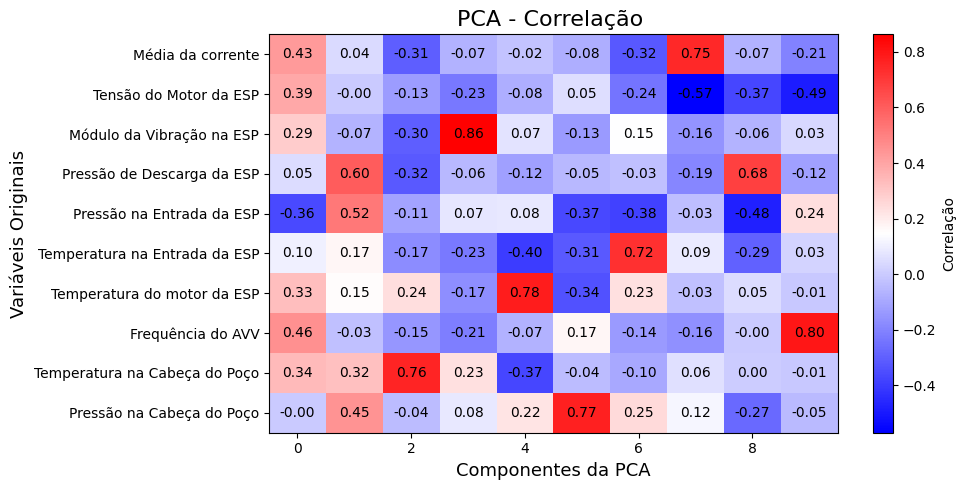

In [3]:
n = 10

operationalHeaders = li.relevantHeader(entireData)

pca = li.AutoModelApplier(PCA(n_components=n),entireData)
fig,axs = li.FigureComponents(pca,operationalHeaders, 
                              listOfNames=["PCA - Correlação ", "Correlação", "Componentes da PCA","Variáveis Originais"],
                              plotName="full_pca_pt",
                              english=False)
PCAdata, PCAHeaders = li.AutoReduce(pca,n,operationalHeaders,entireData)

PCAdata = li.ExportPCAData(PCAdata,entireData)
print(pca.explained_variance_ratio_.cumsum())

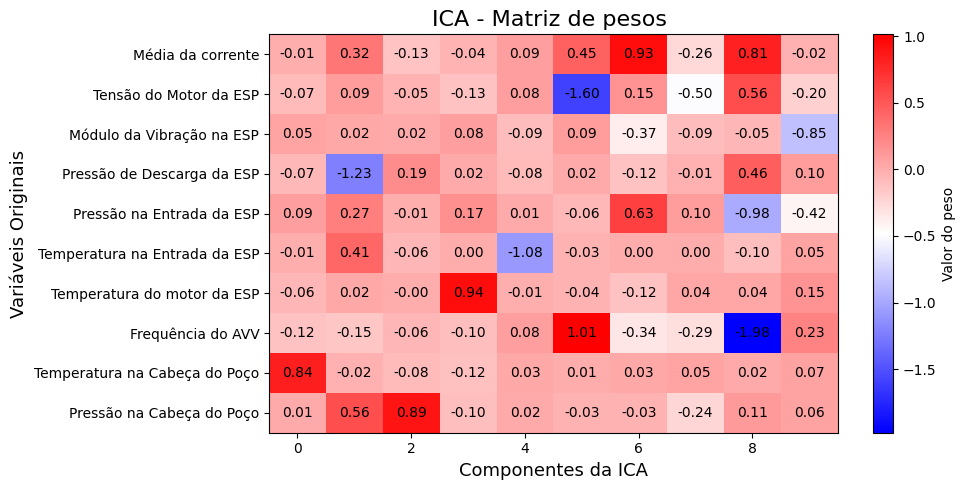

In [4]:
n =10

ica = li.AutoModelApplier(FastICA(n_components=n), entireData)

fig,axs = li.FigureComponents(ica,operationalHeaders, 
                              listOfNames=["ICA - Matriz de pesos ", "Valor do peso", "Componentes da ICA","Variáveis Originais"],
                              plotName="full_ica_pt",
                              english=False)

ICAdata,ICAHeaders = li.AutoReduce(ica,n,operationalHeaders,entireData)


ICAdata = li.ExportPCAData(ICAdata,entireData)

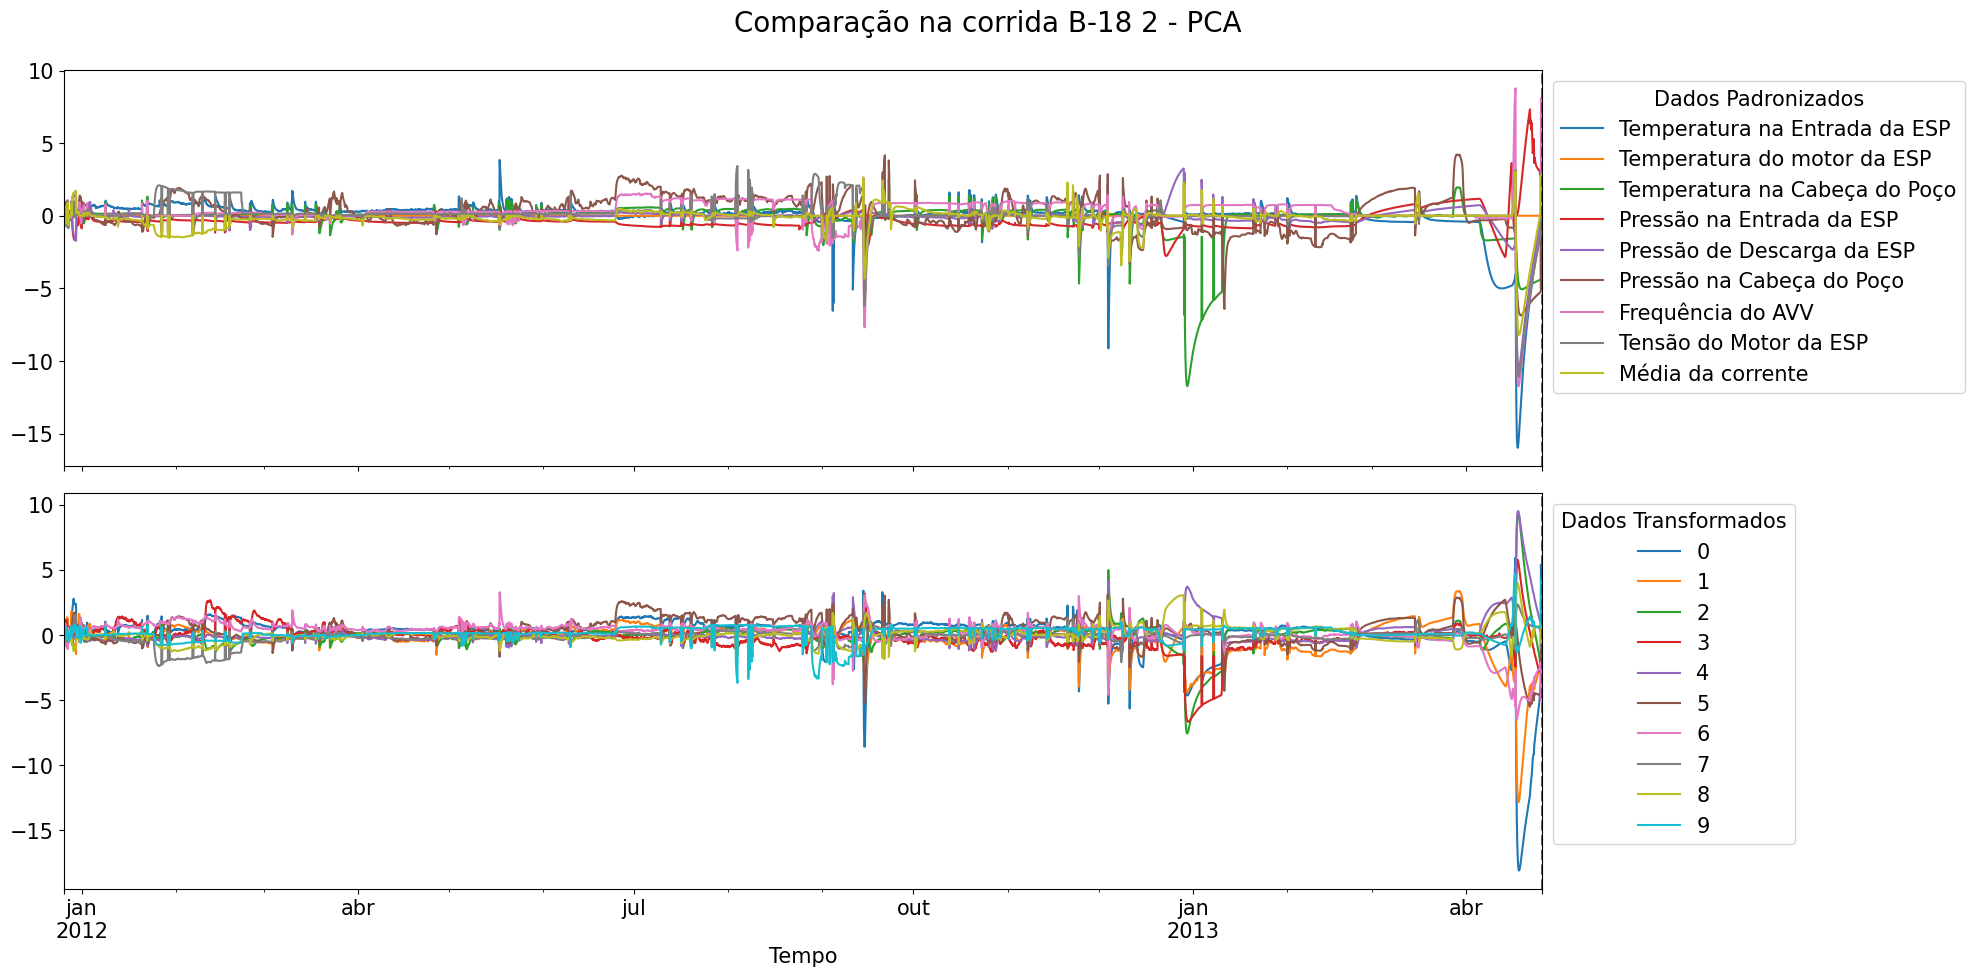

In [29]:
pump = pumpList[0]
pumpDataOriginal = entireData.loc[entireData["Well Run"]==pump].copy()
pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean'
    #'ESP Vibration Module',
    #'ESP Power'
    ]

li.ComparisionPlot(pumpDataOriginal,pumpData,"Comparação na corrida "+pump + " - PCA",PCAHeaders,Headers,english=False,factor=1)
plt.xlabel("Tempo")
plt.savefig("../imagens_gerais/PCA_b_28_2.jpg")

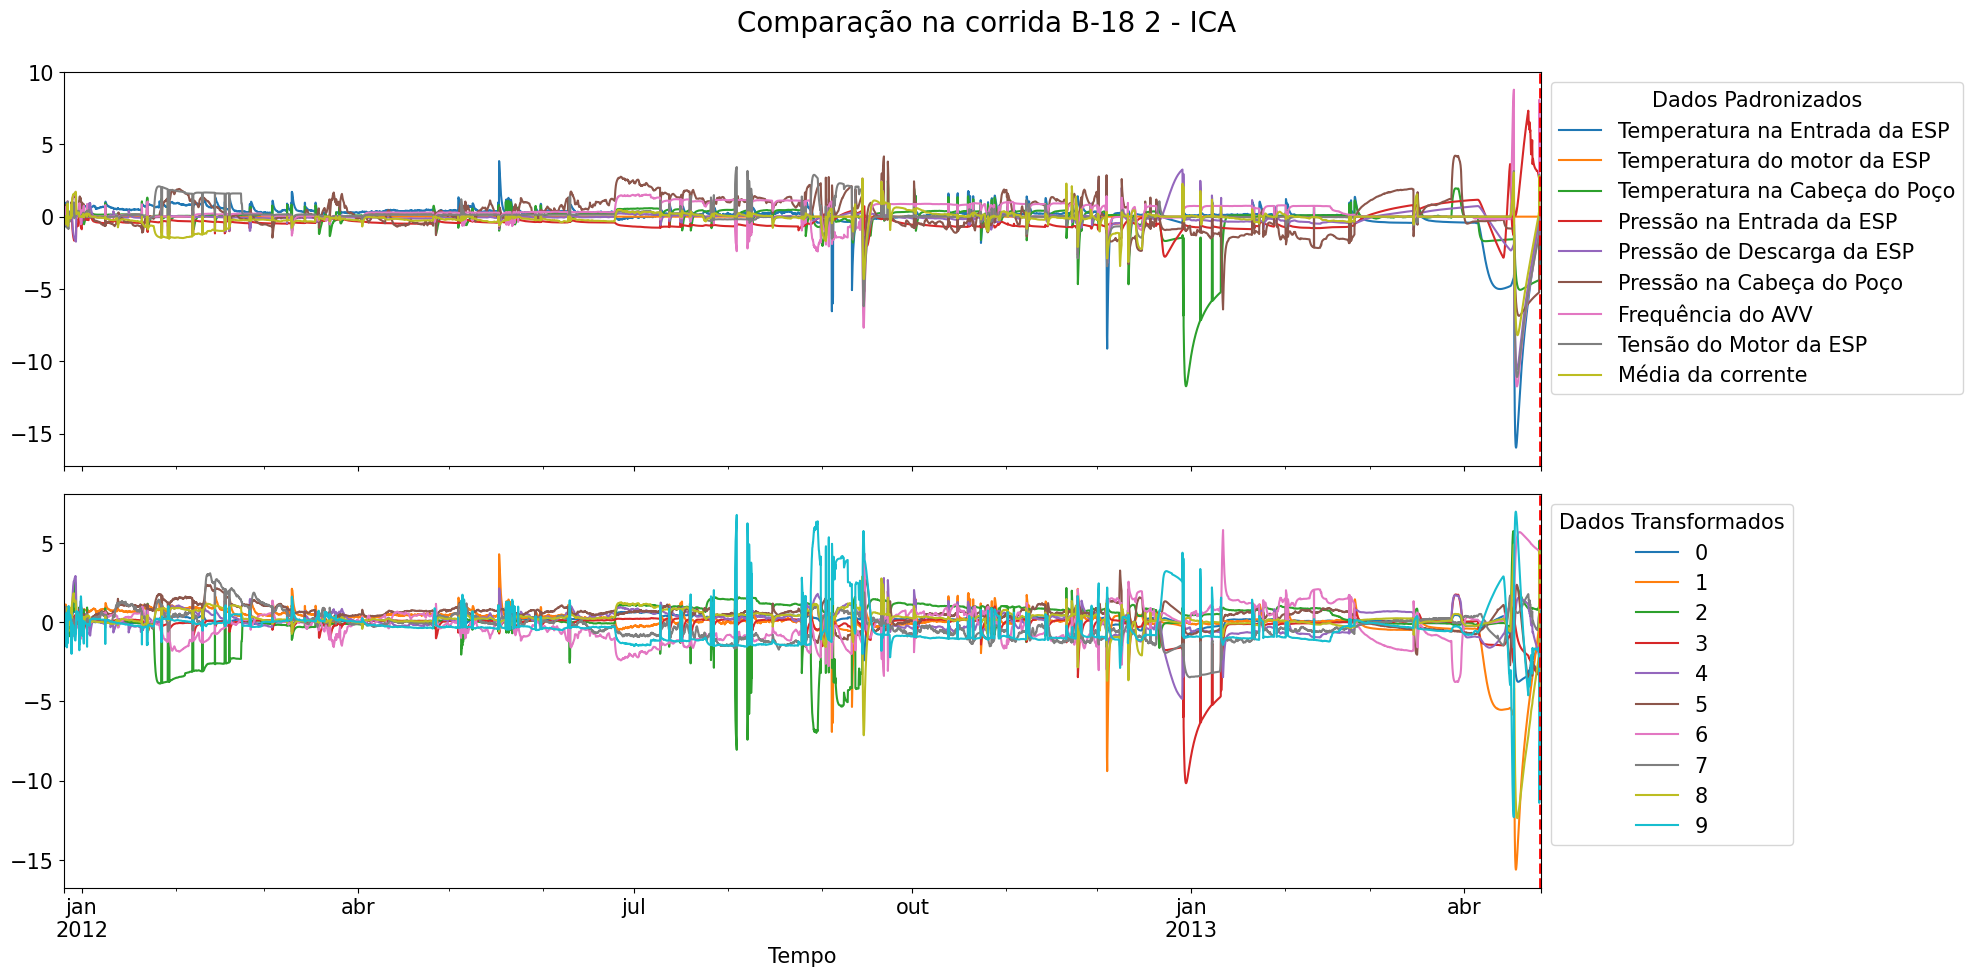

In [30]:
pump = pumpList[0]
pumpDataOriginal = entireData.loc[entireData["Well Run"]==pump].copy()
pumpData = ICAdata.loc[ICAdata["Well Run"]==pump].copy()

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean'
    #'ESP Vibration Module',
    #'ESP Power'
    ]

fig,axs = li.ComparisionPlot(pumpDataOriginal,pumpData,"Comparação na corrida "+pump + " - ICA",ICAHeaders,Headers,english=False,padF = 1.12,figsizeT=(20,10),factor=1)
plt.xlabel("Tempo")
plt.savefig("../imagens_gerais/ICA_b_28_2.jpg")

In [7]:
# pump = pumpList[0]

# entireData.loc[entireData["Well Run"]==pump][operationalHeaders].plot(figsize=(15,7))
# plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
# plt.title(pump + " - Standardized Data")



In [8]:
# PCAdata.loc[PCAdata["Well Run"]==pump][PCAHeaders].plot(figsize=(20,10))
# plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)


In [9]:
# ICAdata.loc[ICAdata["Well Run"]==pumpList[0]][ICAHeaders].plot(figsize=(30,13))

In [10]:
# pump = pumpList[0]

# # pumpData = PCALF.loc[PCALF["Well Run"]==pump].copy()

# # PCAHeaders = [i for i in range(0,componentsLF)]

# pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()




# li.PCAComponentsPlot(pumpData,pump,PCAHeaders)
# plt.tight_layout()

In [11]:
# pumpDataOriginal = entireData.loc[entireData["Well Run"]==pump].copy()

# Headers = [
#     #'ESP discharge temperature sensor',
#     'ESP intake temperature',
#     'ESP motor temperature',
#     'Well head Temperature',
#     'ESP intake Pressure',
#     'ESP discharge pressure',
#     #'ESP differential pressure',
#     'Well head pressure',
#     'VSD power frequency',
#     'ESP Motor Voltage',
#     'Current Mean'
#     #'ESP Vibration Module',
#     #'ESP Power'
#     ]

# li.ComparisionPlot(pumpDataOriginal,pumpData,pump,PCAHeaders,Headers)
# plt.savefig("../imagens_gerais/PCA_b_28_2.jpg")

In [12]:
# pump = pumpList[0]
# plt.rcParams['font.size'] = 15.0

# pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()

# fig, ax = plt.subplots(1,1, figsize=(20,10))

# pumpData[PCAHeaders].plot(ax=ax)

# ax.axvline(pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)
# ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)

# fig.suptitle("PCA Data of " + pump,fontsize=20);


# factor = 0.5


# plt.rcParams.update({
#     'font.size': plt.rcParams['font.size'] * factor,
# })

# #fig.savefig("imagens/relatorio/PCAapplied")

# plt.rcParams['font.size']

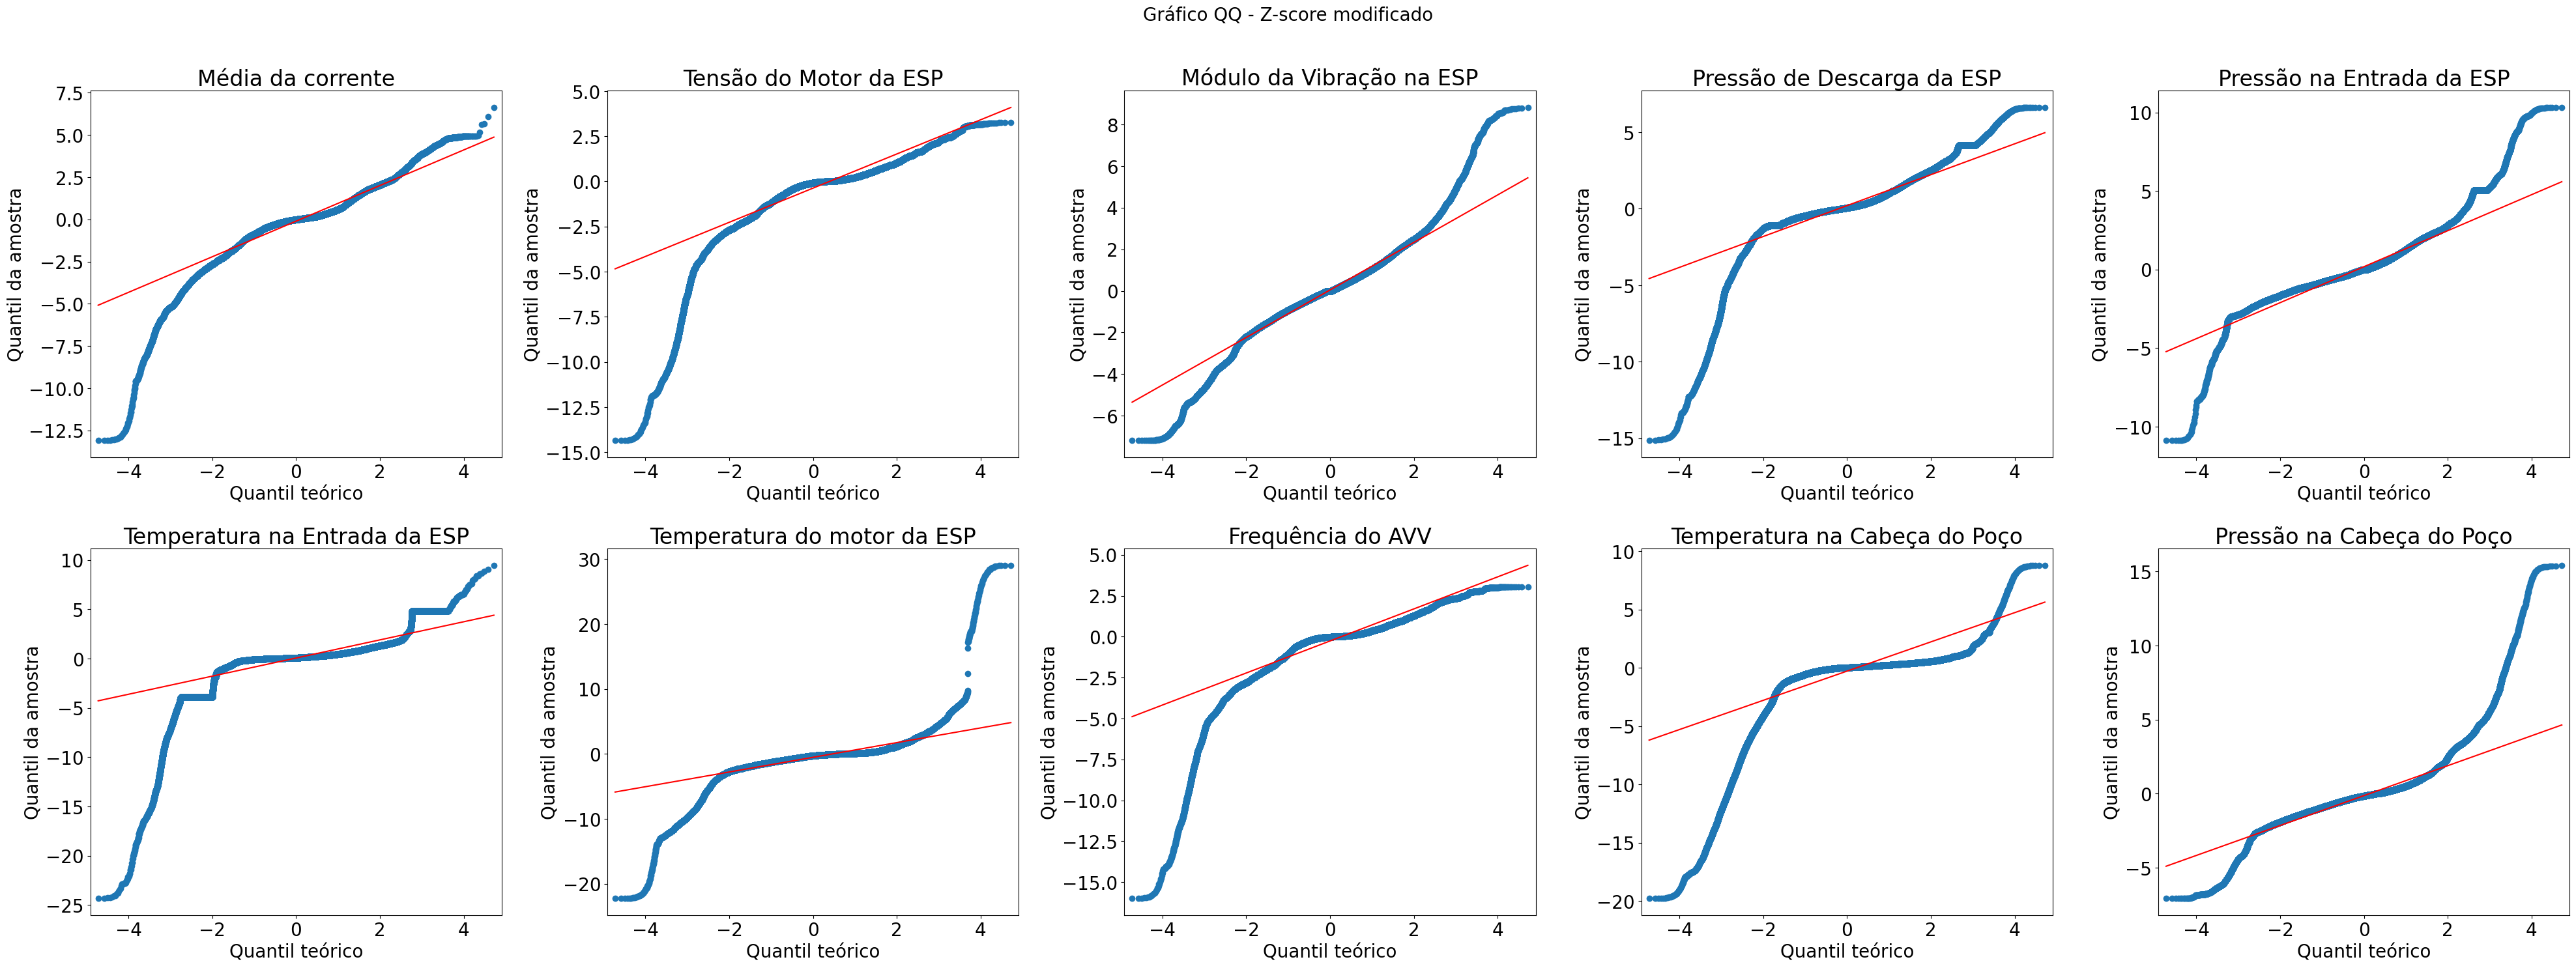

In [15]:
fig,axs = li.QQPlots(
    entireData[operationalHeaders].loc[entireData["Well_down"]==0],
    operationalHeaders, 
    title="Gráfico QQ - Z-score modificado" , 
    lineType="s", 
    english=False,
    titleFontsize=20,
    ydist=1,
    generalFontSize=20
    );
fig.savefig("../imagens_gerais/QQplotZscore",bbox_inches='tight')

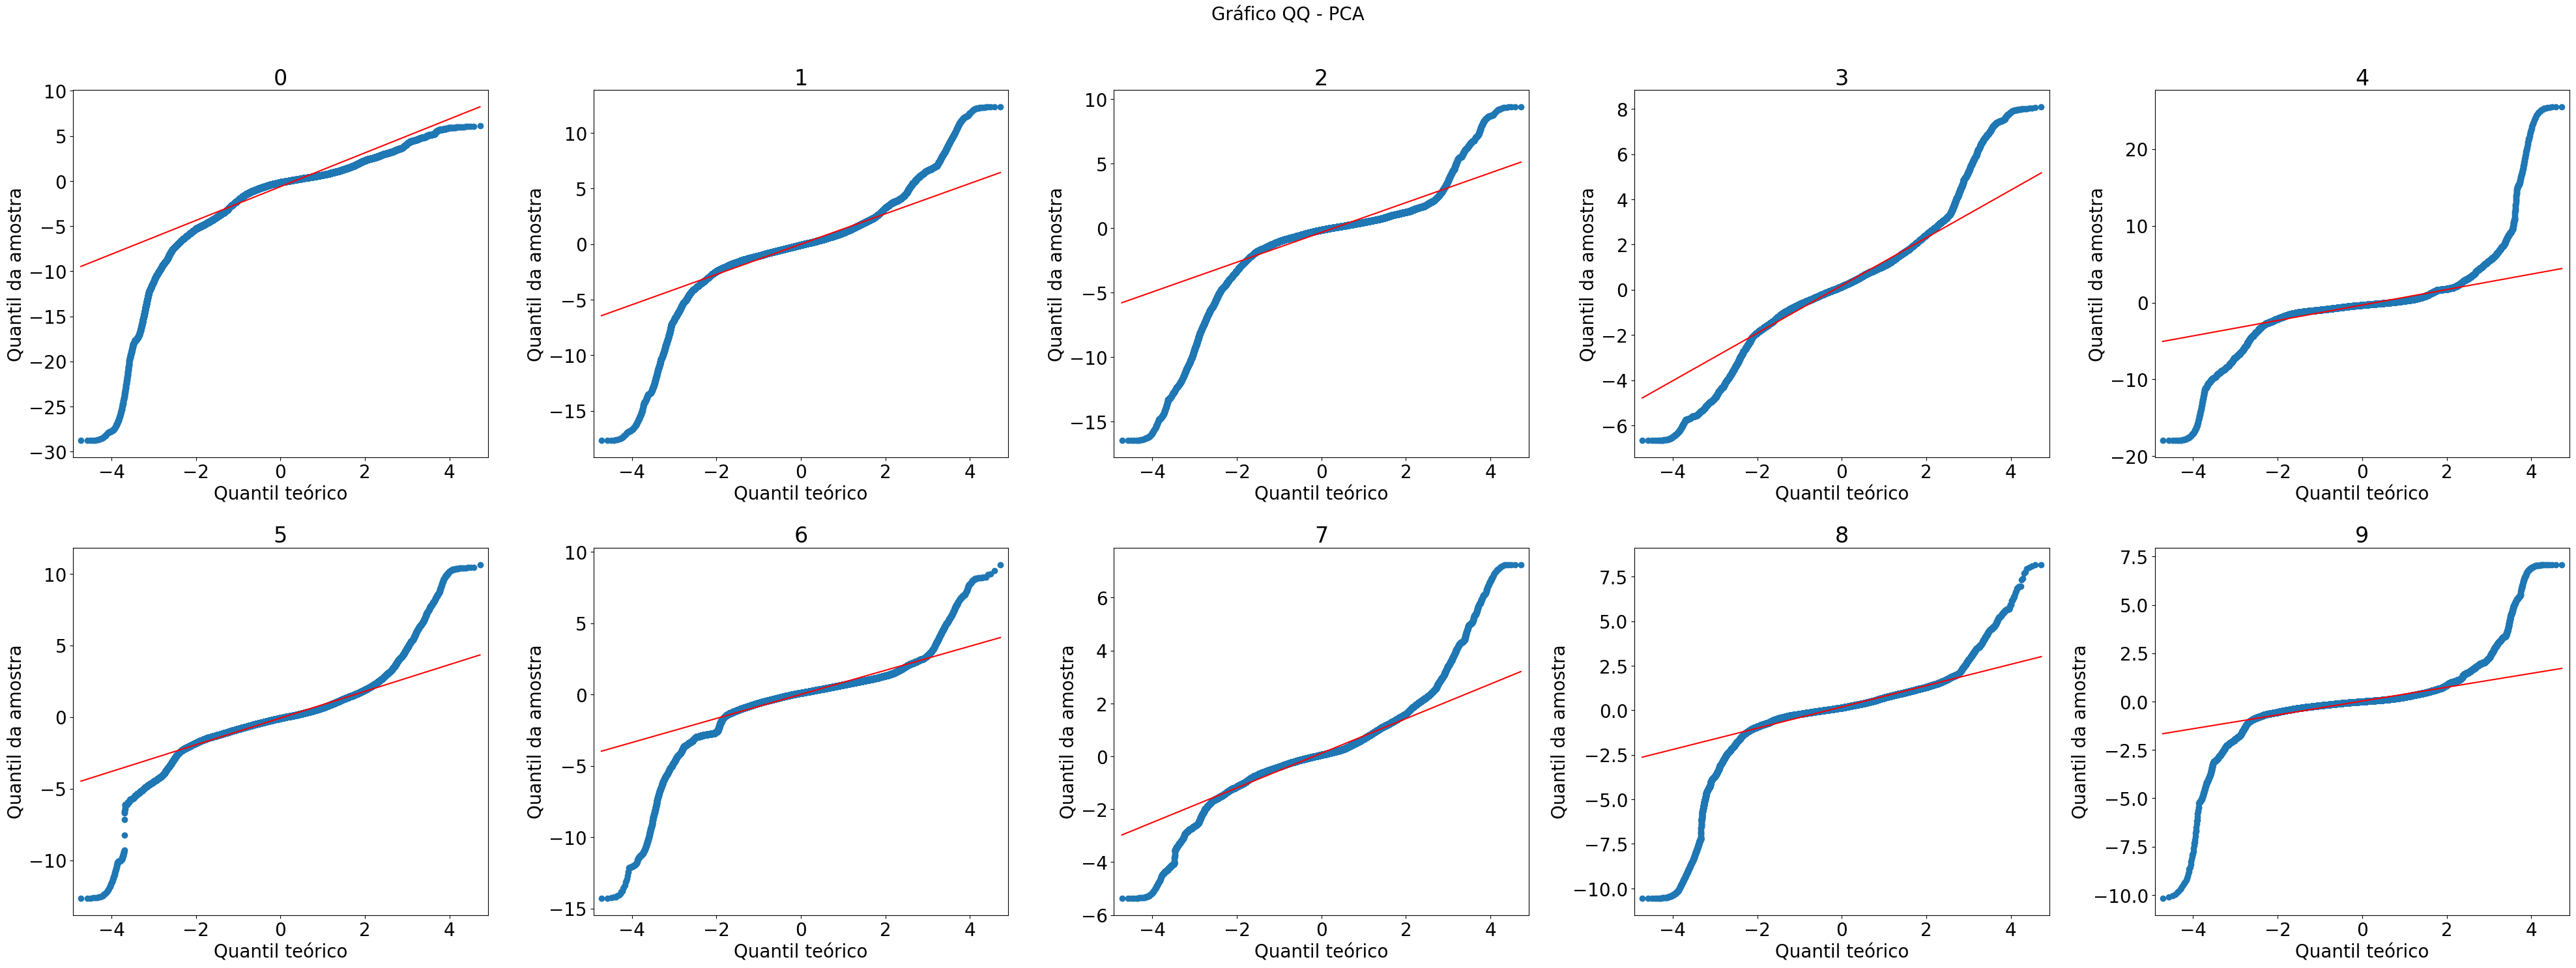

In [ ]:
fig,axs = li.QQPlots(
    PCAdata[PCAHeaders].loc[PCAdata["Well_down"]==0],
    PCAHeaders, title="Gráfico QQ - PCA" , 
    lineType="s", 
    english=False,
    titleFontsize=20,
    ydist=1,
    generalFontSize=20);
fig.savefig("../imagens_gerais/QQplotPCA",bbox_inches='tight')

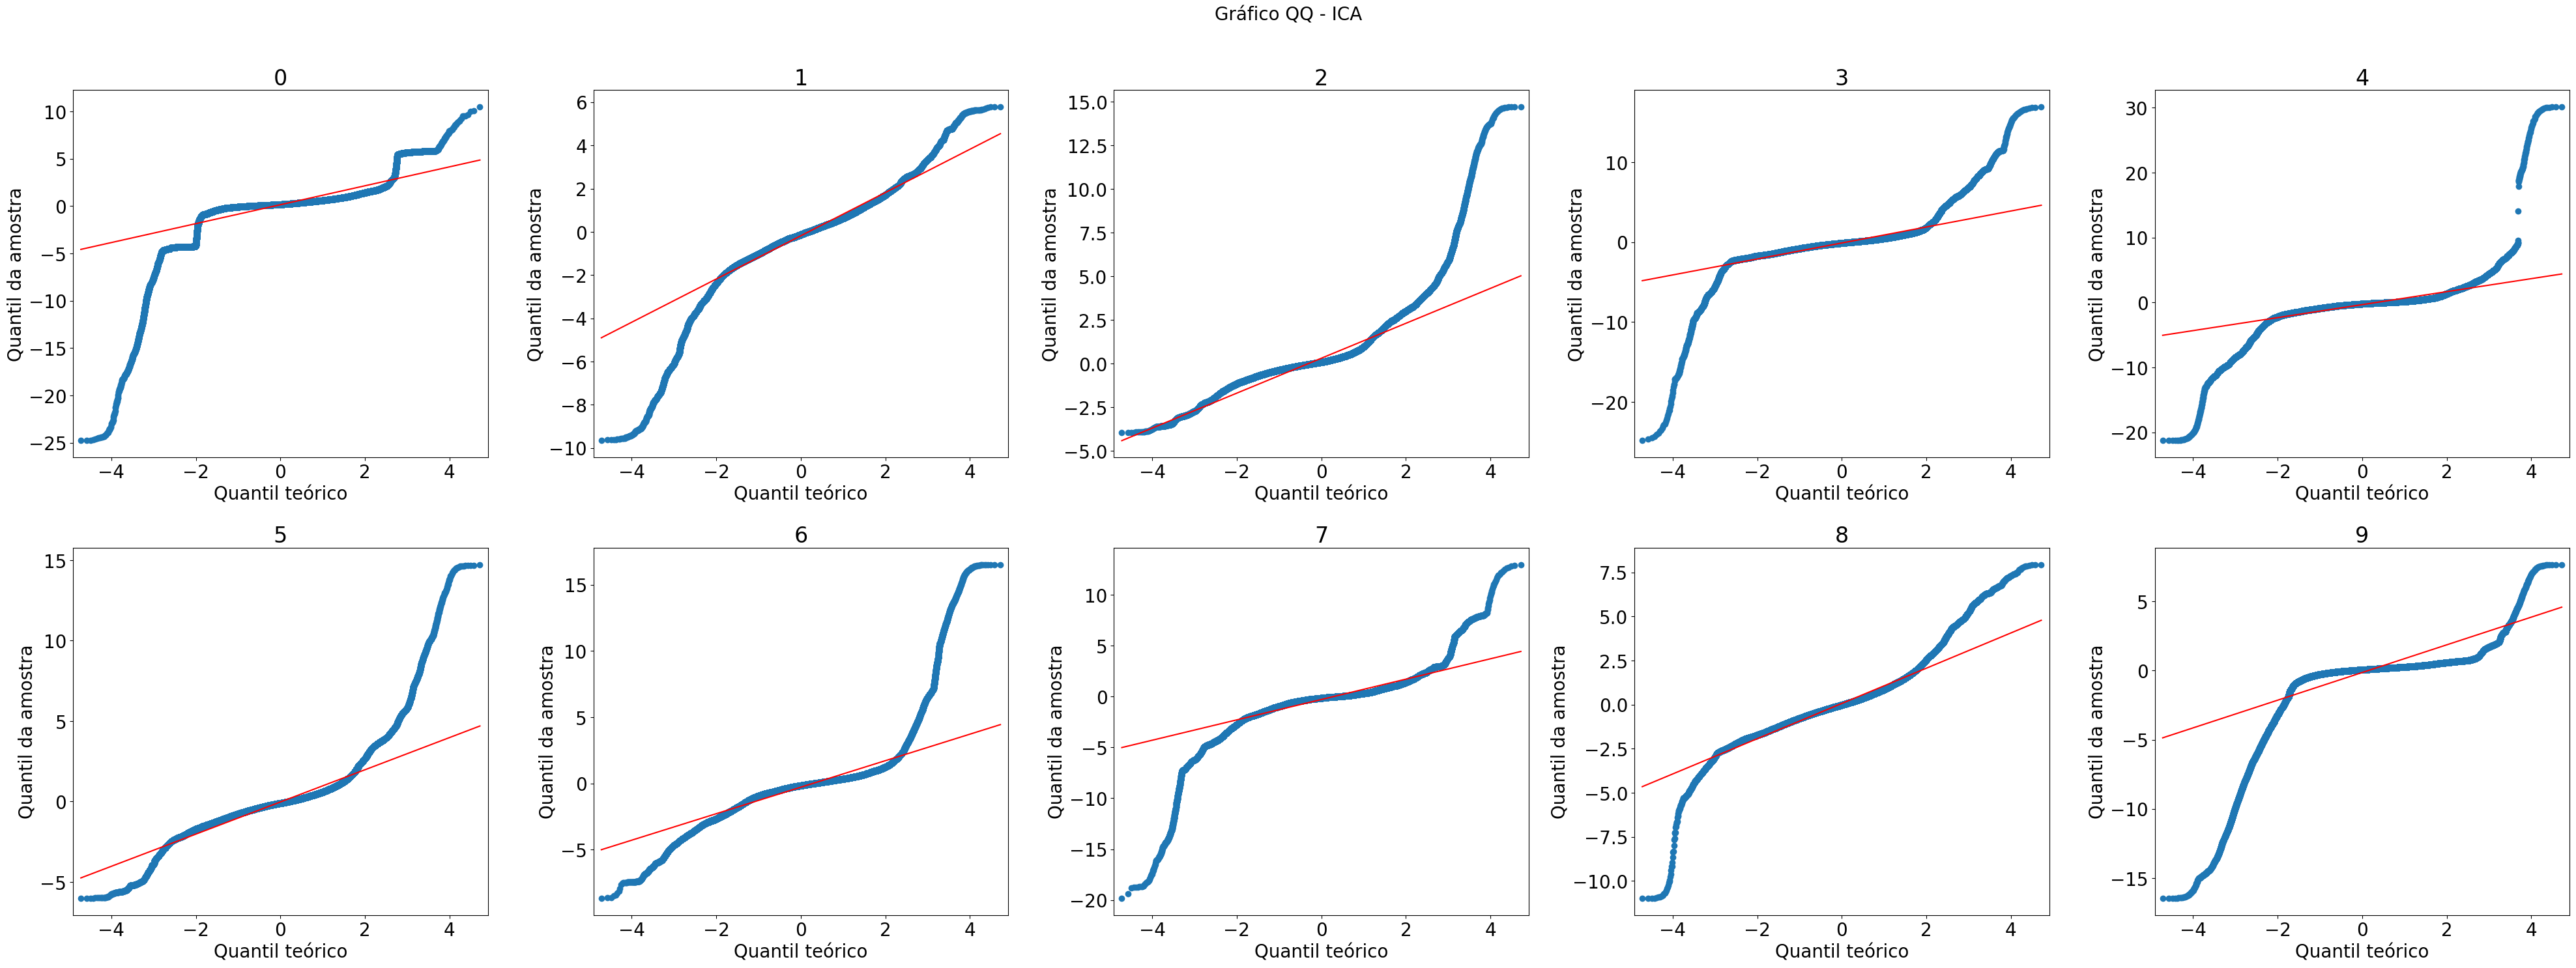

In [18]:
fig,axs = li.QQPlots(
    ICAdata[ICAHeaders].loc[ICAdata["Well_down"]==0],
    ICAHeaders,
    title="Gráfico QQ - ICA", 
    lineType="s", 
    english=False,
    titleFontsize=20,
    ydist=1,
    generalFontSize=20);
fig.savefig("../imagens_gerais/QQplotICA",bbox_inches='tight')

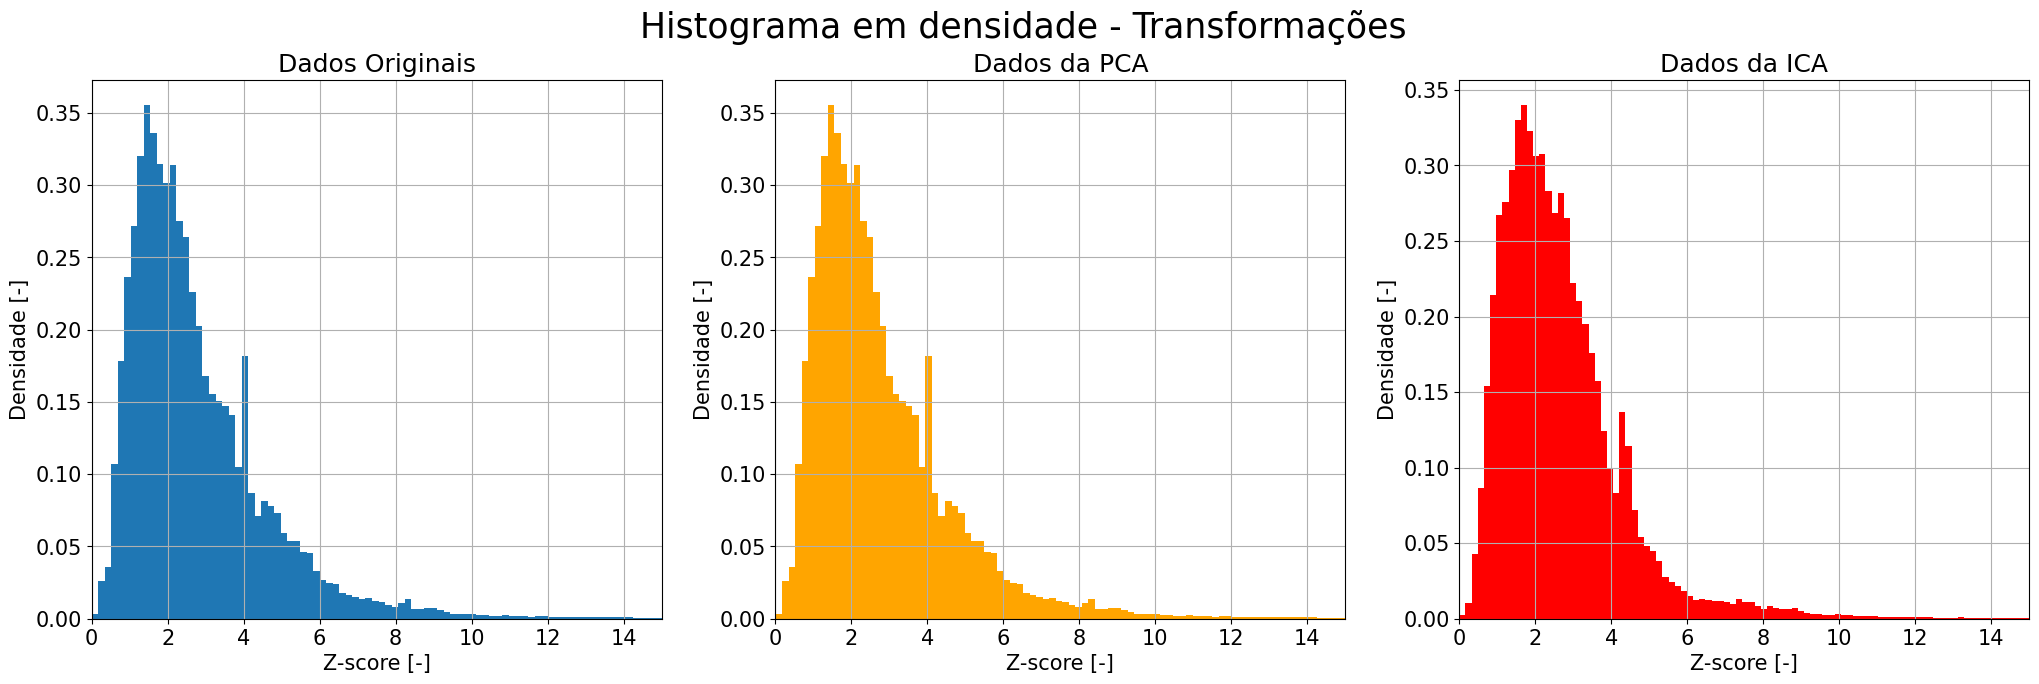

In [37]:
fig,axs = plt.subplots(1,3,figsize=(25,7))

entireData[operationalHeaders].loc[entireData["Well_down"]==0].pow(2).sum(axis=1).pow(1/2).hist(bins=200,ax=axs[0],density=True)
PCAdata[PCAHeaders].loc[PCAdata["Well_down"]==0].pow(2).sum(axis=1).pow(1/2).hist(bins=200,ax=axs[1],color="orange",density=True)
ICAdata[PCAHeaders].loc[ICAdata["Well_down"]==0].pow(2).sum(axis=1).pow(1/2).hist(bins=200,ax=axs[2],color="red",density=True)


axs[0].set_title("Dados Originais")
axs[0].set_xlabel("Z-score [-]")
axs[0].set_ylabel("Densidade [-]")
axs[0].set_xlim((0,15))


axs[1].set_title("Dados da PCA")
axs[1].set_xlabel("Z-score [-]")
axs[1].set_ylabel("Densidade [-]")
axs[1].set_xlim((0,15))

axs[2].set_title("Dados da ICA")
axs[2].set_xlabel("Z-score [-]")
axs[2].set_ylabel("Densidade [-]")
axs[2].set_xlim((0,15))

fig.suptitle("Histograma em densidade - Transformações ",fontsize=25)

fig.savefig("../imagens_gerais/histograma_transformacoes")

In [32]:
# PCAdata[PCAHeaders].loc[PCAdata["Well_down"]==0].pow(2).sum(axis=1).pow(1/2).hist(bins=200,color="orange",density=True,figsize=(10,7))
# ICAdata[PCAHeaders].loc[ICAdata["Well_down"]==0].pow(2).sum(axis=1).pow(1/2).hist(bins=200,color="red",density=True,alpha=1)
# entireData[operationalHeaders].loc[entireData["Well_down"]==0].pow(2).sum(axis=1).pow(1/2).hist(bins=200,density=True,alpha=1)
# plt.xlim((0,15))

In [18]:
# axes = ICAdata.loc[ICAdata["Well_down"]==0][ICAHeaders].hist(bins=50,figsize=(20,18))

# i = 0
# #measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","V","A","g","g","-"]


# for ax in axes.flatten():
#     ax.set_xlabel("Valores [-]" )  # Define a legenda com o nome da coluna
#     ax.set_ylabel("Contagem")
#     i += 1


# plt.suptitle("Histogramas dos dados transformados pela ICA",fontsize=20,y=1)
# plt.tight_layout(pad=1.5)
# plt.savefig("../imagens_gerais/hist_ICA.jpg")

In [19]:
# axes = PCAdata.loc[PCAdata["Well_down"]==0][PCAHeaders].hist(bins=50,figsize=(20,18))

# i = 0
# #measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","V","A","g","g","-"]


# for ax in axes.flatten():
#     ax.set_xlabel("Valores [-]" )  # Define a legenda com o nome da coluna
#     ax.set_ylabel("Contagem")
#     i += 1


# plt.suptitle("Histogramas dos dados transformados pela PCA",fontsize=20,y=1)
# plt.tight_layout(pad=1.5)
# plt.savefig("../imagens_gerais/hist_PCA.jpg")

In [20]:
ChiDist = pd.DataFrame(columns=["ZSC","PCA","ICA"],index=entireData.loc[entireData["Well_down"]==0].index)

ChiDist["ICA"] = ICAdata[ICAHeaders].loc[ICAdata["Well_down"]==0].pow(2).sum(axis=1).pow(1/2)
ChiDist["PCA"] = PCAdata[PCAHeaders].loc[PCAdata["Well_down"]==0].pow(2).sum(axis=1).pow(1/2)
ChiDist["ZSC"] = entireData[operationalHeaders].loc[entireData["Well_down"]==0].pow(2).sum(axis=1).pow(1/2)

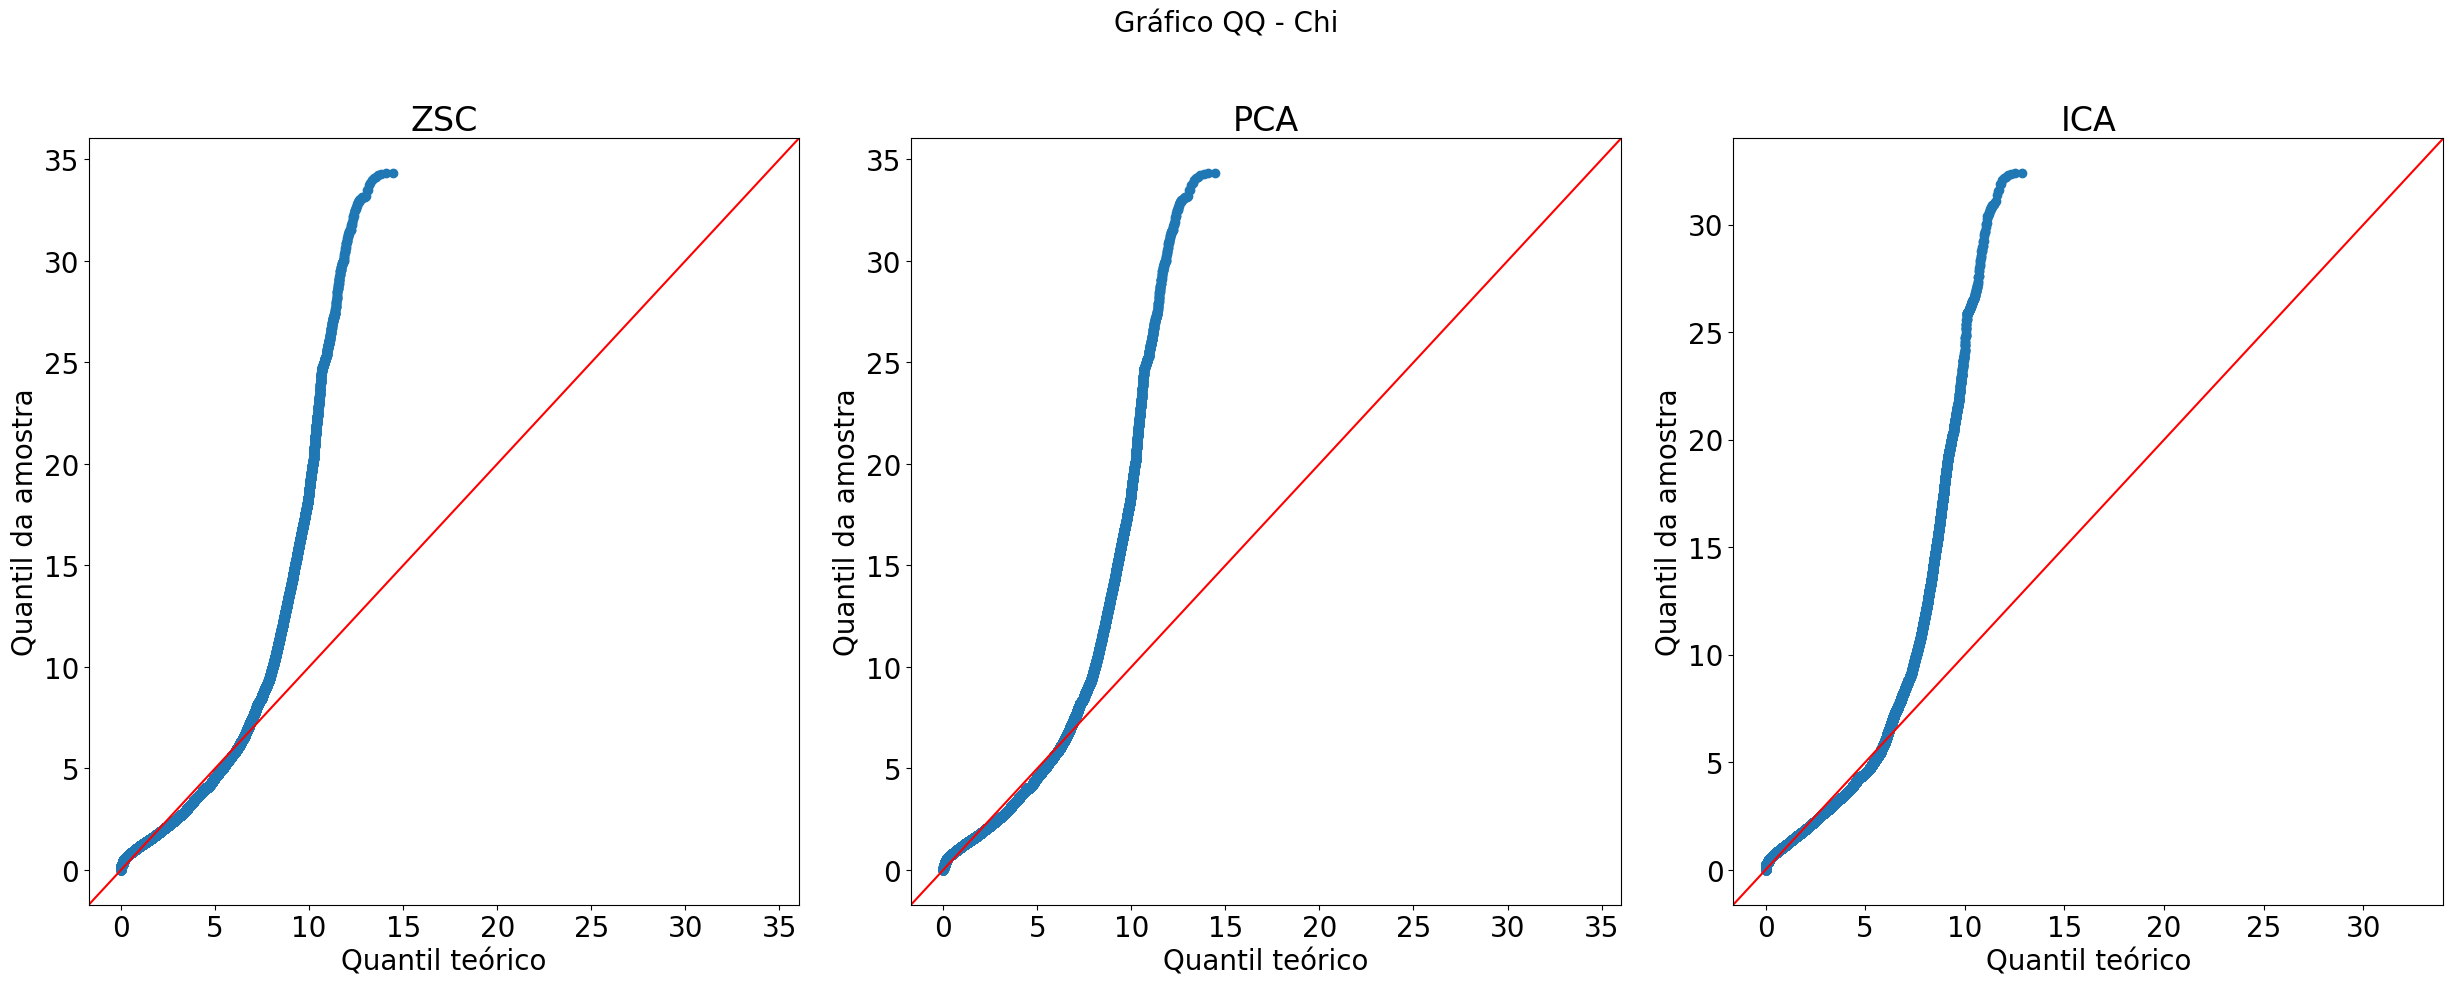

In [23]:
plt.rcParams["font.size"]=20

fig, axs = plt.subplots(1,3,figsize=(25,10))    

fig.suptitle("Gráfico QQ - Chi",fontsize=20, y=1)    

props = ["ZSC","PCA","ICA"]



for i in range(0,3):
    df,loc,scale = ss.distributions.chi.fit(ChiDist[props[i]])
    sm.qqplot(ChiDist[props[i]], line="45",ax=axs[i],dist=ss.distributions.chi(df,loc,scale))
    axs[i].title.set_text(props[i])
    axs[i].set_xlabel("Quantil teórico")
    axs[i].set_ylabel("Quantil da amostra")

fig.tight_layout(pad=1.2)
fig.savefig("../imagens_gerais/QQChi")


(1.0, 0, 1.05)